In [6]:
import cv2
img=cv2.imread(r'C:\Users\Nawam Perera\Pictures\hhhh.png')
cv2.imshow('6f6f6t',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# Q1 part a
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
img=cv.imread(r'C:\Users\Nawam Perera\Downloads\runway.png',cv.IMREAD_GRAYSCALE)
img1=img/255

gamma=0.5
a=img1**gamma
cv.imshow('Gamma 0.5 img1',a)
cv.waitKey(0)
cv.destroyAllWindows()


In [ ]:
#Q1 part b
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
img=cv.imread(r'C:\Users\Nawam Perera\Downloads\runway.png',cv.IMREAD_GRAYSCALE)
img1=img/255
gamma=2
a=img1**gamma
cv.imshow('Gamma 2 img1',a)
cv.waitKey(0)
cv.destroyAllWindows()


In [5]:
#Q1 part c
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
img=cv.imread(r'C:\Users\Nawam Perera\Downloads\runway.png',cv.IMREAD_GRAYSCALE)
img1=img/255

r1,r2=0.2,0.8
output=np.zeros_like(img1)

output[img1>=r1]=0
output[(img1>=r1)&(img1<=r2)]=\
    (img1[(img1>=r1)&(img1<=r2)]-r1)/(r2-r1)
output[img1>r2]=1

output01=np.uint8(output*255)

cv.imshow('Result',output01)
cv.waitKey(0) 
cv.destroyAllWindows()

In [ ]:
#Q2 part a
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img=cv.imread(r'C:\Users\Nawam Perera\Downloads\highlights_and_shadows.jpg')
LAB=cv.cvtColor(img,cv.COLOR_BGR2LAB)
L,A,B=cv.split(LAB)
Gamma=0.6
L_Norm=L/255
L_Gamma=np.power(L_Norm,Gamma)
L_Gamma=np.uint8(L_Gamma*255)

LAB_out=cv.merge((L_Gamma,A,B))
out=cv.cvtColor(LAB_out,cv.COLOR_LAB2BGR)


cv.imshow('Result02',out)
cv.waitKey(0) 
cv.destroyAllWindows()


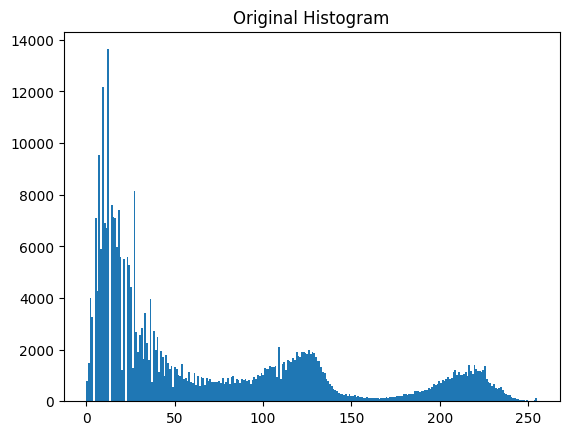

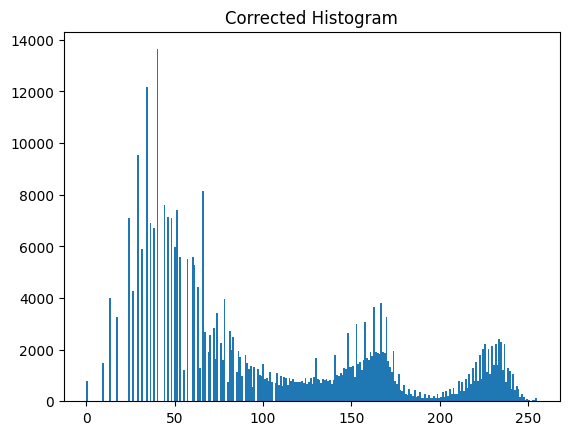

In [ ]:
#Q2 part b
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

plt.hist(L.flatten(),256)
plt.title('Original Histogram')
plt.show()

plt.hist(L_Gamma.flatten(),256)
plt.title('Corrected Histogram')
plt.show()


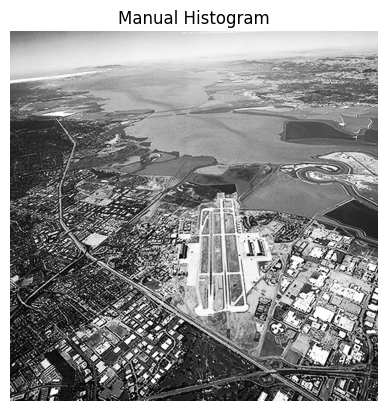

In [ ]:

#Q3 
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img=cv.imread(r'C:\Users\Nawam Perera\Downloads\runway.png',cv.IMREAD_GRAYSCALE)
hist,_=np.histogram(img.flatten(),256,
[0,256])
cdf=hist.cumsum()
cdf=cdf/cdf[-1]
out=np.interp(img.flatten(),range(256),cdf*255)
out=out.reshape(img.shape).astype(np.uint8)

plt.imshow(out,cmap='gray')
plt.title('Manual Histogram')
plt.axis('off')
plt.show()


In [ ]:
#Q4
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img=cv.imread(r'C:\Users\Nawam Perera\Downloads\looking_out.jpg',cv.IMREAD_GRAYSCALE)

cv.imshow('GRAY PHOTO',img)
cv.waitKey(0)
cv.destroyAllWindows()


Otsu Threshold= 101.0


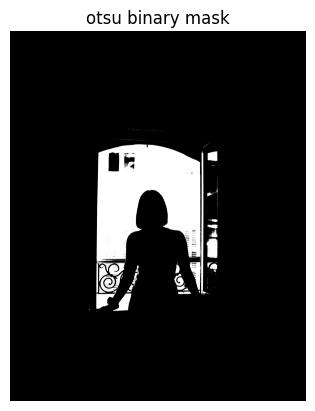

In [21]:
#Q4 part a
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread(r'C:\Users\Nawam Perera\Downloads\looking_out.jpg',cv.IMREAD_GRAYSCALE)

th,mask=cv.threshold(img,0,255,
cv.THRESH_BINARY + cv.THRESH_OTSU)
print('Otsu Threshold=',th)

plt.imshow(mask,cmap='gray')
plt.title('otsu binary mask')
plt.axis('off')
plt.show()

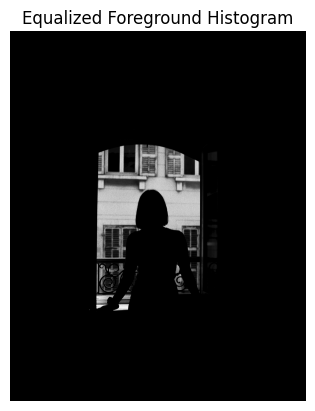

In [28]:
#Q4 part b
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

fg=cv.bitwise_and(img,img,mask=mask)

hist_=np.histogram(fg.flatten(),256,
[0,256])
cdf=hist.cumsum()
cdf=cdf/cdf[-1]
out=np.interp(fg.flatten(),range(256),
cdf*255)
out=out.reshape(fg.shape).astype(np.uint8)

plt.imshow(out,cmap='gray')
plt.title('Equalized Foreground Histogram')
plt.axis('off')
plt.show()

In [31]:
#Q5 part a
import numpy as np
sigma=2
ax=np.arange(-2,3)
x,y=np.meshgrid(ax,ax)
kernel=np.exp(-(x**2 + y**2)/(2*sigma**2))
kernel=kernel/np.sum(kernel)

print(kernel)


[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


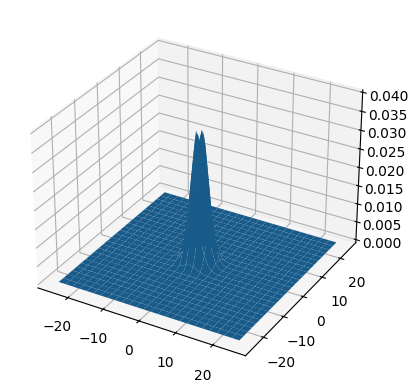

In [35]:
#Q5 part b
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

ax = np.arange(-25,26)
x,y = np.meshgrid(ax,ax)
sigma = 2
kernel = np.exp(-(x**2 + y**2) / (2*sigma*2))
kernel /= kernel.sum()

fig = plt.figure()
ax3d = fig.add_subplot(111, projection='3d')
ax3d.plot_surface(x, y, kernel)
plt.show()

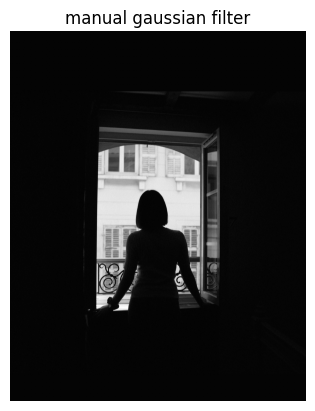

In [40]:
#Q5 part c
import cv2
import matplotlib.pyplot as plt

out = cv2.filter2D(img, -1, kernel)

plt.imshow(out, cmap='gray')
plt.title("manual gaussian filter")
plt.axis('off')
plt.show()

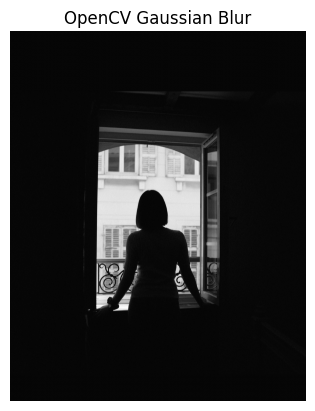

In [43]:
#Q5 part d
import cv2 as cv
import matplotlib.pyplot as plt

out = cv.GaussianBlur(img, (5,5), 2)

plt.imshow(out, cmap='gray')
plt.title("OpenCV Gaussian Blur")
plt.axis('off')
plt.show()

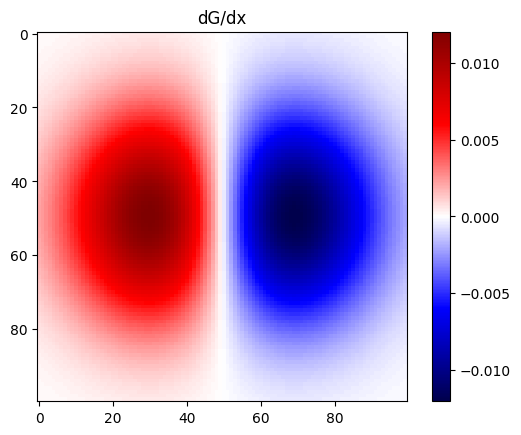

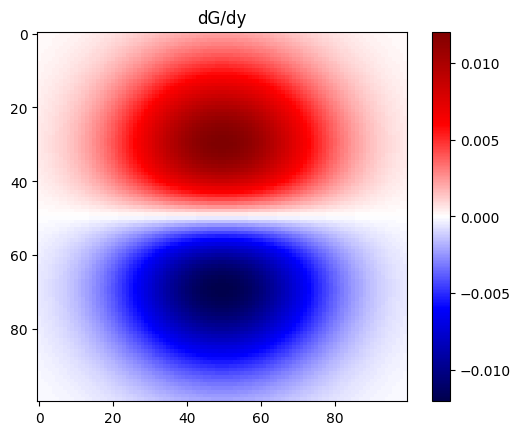

In [51]:
#Q6 part a
import numpy as np
import matplotlib.pyplot as plt

sigma = 2
ax = np.linspace(-5, 5, 100)
x, y = np.meshgrid(ax, ax)

G = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))
Gx = -x/(sigma**2) * G
Gy = -y/(sigma**2) * G

plt.imshow(Gx, cmap='seismic')
plt.title("dG/dx")
plt.colorbar()
plt.show()

plt.imshow(Gy, cmap='seismic')
plt.title("dG/dy")
plt.colorbar()
plt.show()

In [46]:
#Q6 part b
import numpy as np

sigma = 2
ax = np.arange(-2, 3)
x, y = np.meshgrid(ax, ax)

G = np.exp(-(x**2 + y**2)/(2*sigma**2))
G = G / G.sum()

Gx = -x/(sigma**2) * G
Gy = -y/(sigma**2) * G

print("DoG Kernel (X-direction):\n", Gx)
print("\nDoG Kernel (Y-direction):\n", Gy)

DoG Kernel (X-direction):
 [[ 0.01162342  0.00845599  0.         -0.00845599 -0.01162342]
 [ 0.01691198  0.01230339  0.         -0.01230339 -0.01691198]
 [ 0.01916378  0.01394157  0.         -0.01394157 -0.01916378]
 [ 0.01691198  0.01230339  0.         -0.01230339 -0.01691198]
 [ 0.01162342  0.00845599  0.         -0.00845599 -0.01162342]]

DoG Kernel (Y-direction):
 [[ 0.01162342  0.01691198  0.01916378  0.01691198  0.01162342]
 [ 0.00845599  0.01230339  0.01394157  0.01230339  0.00845599]
 [ 0.          0.          0.          0.          0.        ]
 [-0.00845599 -0.01230339 -0.01394157 -0.01230339 -0.00845599]
 [-0.01162342 -0.01691198 -0.01916378 -0.01691198 -0.01162342]]


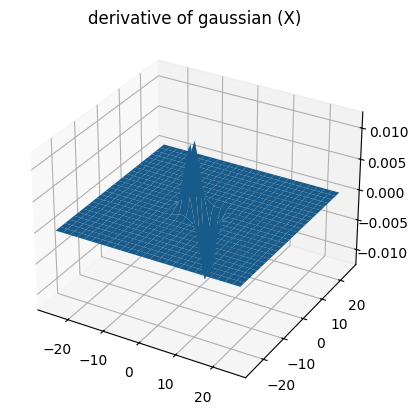

In [48]:
#Q6 part c
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sigma = 2
ax = np.arange(-25, 26)
x, y = np.meshgrid(ax, ax)

G = np.exp(-(x**2 + y**2)/(2*sigma**2))
G = G / G.sum()
Gx = -x/(sigma**2) * G

fig = plt.figure()
ax3d = fig.add_subplot(111, projection='3d')
ax3d.plot_surface(x, y, Gx)
plt.title("derivative of gaussian (X)")
plt.show()

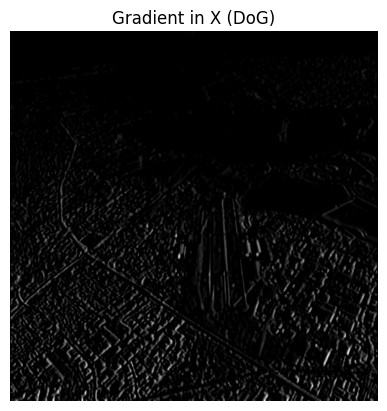

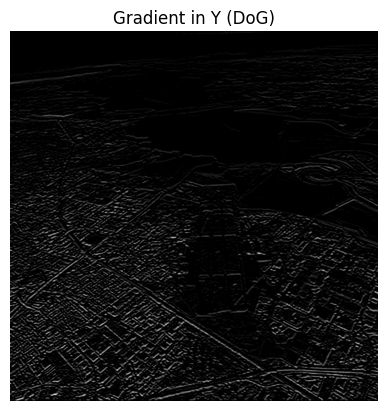

In [49]:
#Q6 part d
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread(r'C:\Users\Nawam Perera\Downloads\runway.png', cv2.IMREAD_GRAYSCALE)

Ix = cv.filter2D(img, -1, Gx)
Iy = cv.filter2D(img, -1, Gy)

plt.imshow(Ix, cmap='gray')
plt.title("Gradient in X (DoG)")
plt.axis('off')
plt.show()

plt.imshow(Iy, cmap='gray')
plt.title("Gradient in Y (DoG)")
plt.axis('off')
plt.show()

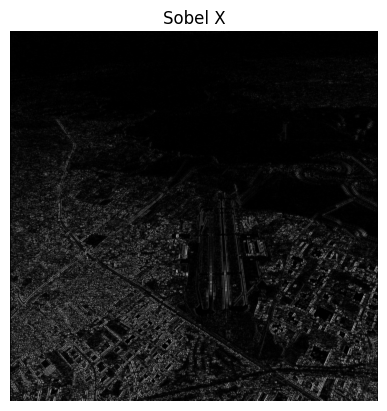

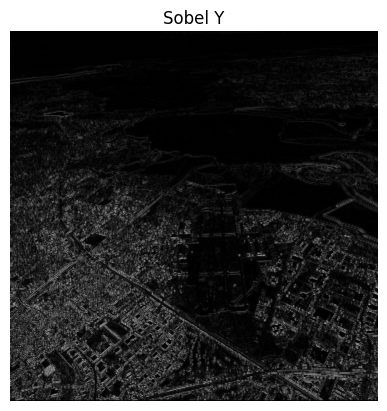

In [50]:
#Q6 part e
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

sx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
sy = cv2.Sobel(img, cv2.CV_64F, 0, 1)

plt.imshow(np.abs(sx), cmap='gray')
plt.title("Sobel X")
plt.axis('off')
plt.show()

plt.imshow(np.abs(sy), cmap='gray')
plt.title("Sobel Y")
plt.axis('off')
plt.show()

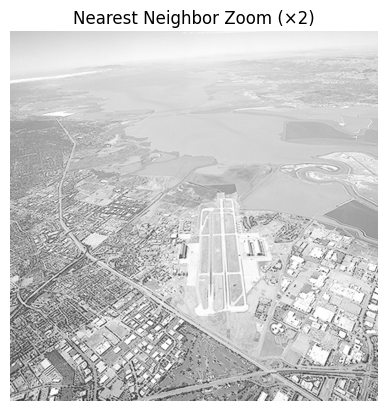

In [53]:
#Q7 part a
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r'C:\Users\Nawam Perera\Downloads\runway.png', cv2.IMREAD_GRAYSCALE)

def zoom_nn(img, s):
    h, w = img.shape
    out = np.zeros((int(h*s), int(w*s)), dtype=img.dtype)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = img[int(i/s), int(j/s)]
    return out

out = zoom_nn(img, 2)

plt.imshow(out, cmap='gray')
plt.title("Nearest Neighbor Zoom (×2)")
plt.axis('off')
plt.show()

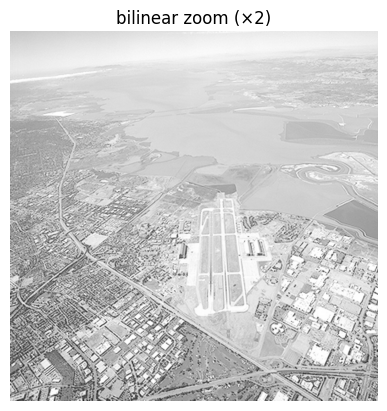

In [ ]:
#Q7 part b
import cv2
import matplotlib.pyplot as plt

# -------- Bilinear --------
out = cv2.resize(img, None, fx=2, fy=2,
                 interpolation=cv2.INTER_LINEAR)

plt.imshow(out, cmap='gray')
plt.title("bilinear zoom (×2)")
plt.axis('off')
plt.show()